# PEA-STA Analysis

In [1]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt


In [2]:
def load_labels():
    cell_stage = np.array(pd.read_csv("../data/PEA_STA/cell_stage.csv", header=None))[0]
    labels = []
    for each in cell_stage:
        day = each.split("_")[1]
        treat = each.split("_")[2]
        if day == "0h":
            labels.append("0h untreated")
        elif day == "6d":
            if treat == "contol":
                labels.append("6d untreated")
            elif treat == "BMP4":
                labels.append("BMP4 treated")

    return labels

In [3]:
cell_embeddings = pd.read_csv('../embeddings/scoit/PEA_STA/cell_embeddings.csv', header=None)
gene_embeddings = pd.read_csv('../embeddings/scoit/PEA_STA/gene_embeddings.csv', header=None)

local_gene_embeddings = pd.read_csv('../embeddings/scoit/PEA_STA/local_gene_embeddings.csv', header=None)
local_cell_embeddings = pd.read_csv('../embeddings/scoit/PEA_STA/local_cell_embeddings.csv', header=None)

omics_embeddings = pd.read_csv('../embeddings/scoit/PEA_STA/omics_embeddings.csv', header=None)

labels = load_labels()

## A. Cell Embeddings UMAP

Text(0, 0.5, 'UMAP_2')

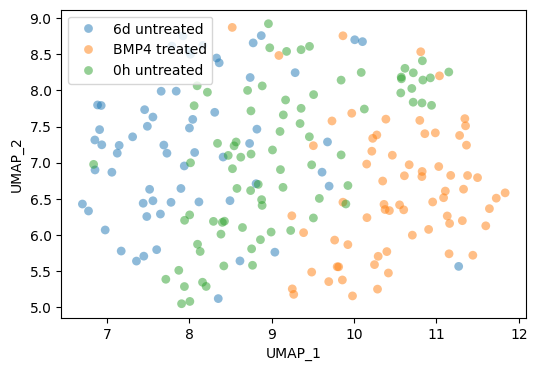

In [4]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings.values)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=labels,
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


## Cell Clustering

In [5]:
from scoit.cell_analysis import cluster_evaluate

cluster_evaluate(cell_embeddings, labels)

{'NMI': 0.33503719672894766,
 'ARI': 0.2981077802309789,
 'FMI': 0.539775913198602}